In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\merve\Desktop\Calismalar\E-Commerce-Uns\data.csv",encoding='ISO-8859-1')

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.InvoiceNo.value_counts()

InvoiceNo
573585     1114
581219      749
581492      731
580729      721
558475      705
           ... 
581487        1
581491        1
C581499       1
581566        1
C581568       1
Name: count, Length: 25900, dtype: int64

In [8]:
df.InvoiceDate.value_counts()

InvoiceDate
10/31/2011 14:41    1114
12/8/2011 9:28       749
12/9/2011 10:03      731
12/5/2011 17:24      721
6/29/2011 15:58      705
                    ... 
12/9/2011 9:44         1
12/9/2011 10:02        1
12/9/2011 10:28        1
12/9/2011 11:50        1
12/9/2011 11:57        1
Name: count, Length: 23260, dtype: int64

In [9]:
df.CustomerID.value_counts()

CustomerID
17841.0    7983
14911.0    5903
14096.0    5128
12748.0    4642
14606.0    2782
           ... 
18184.0       1
13256.0       1
13017.0       1
18174.0       1
15195.0       1
Name: count, Length: 4372, dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [17]:
df = df.dropna(subset=['CustomerID', 'Description'])

In [18]:
#CustomerID'yi stringe çevirelim

df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  str    
 1   StockCode    406829 non-null  str    
 2   Description  406829 non-null  str    
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  str    
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  str    
 7   Country      406829 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 27.9 MB


In [20]:
df.describe()

,Quantity,UnitPrice
count,406829.000000,406829.000000
mean,12.061303,3.460471
std,248.693370,69.315162
min,-80995.000000,0.000000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,38970.000000


In [21]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

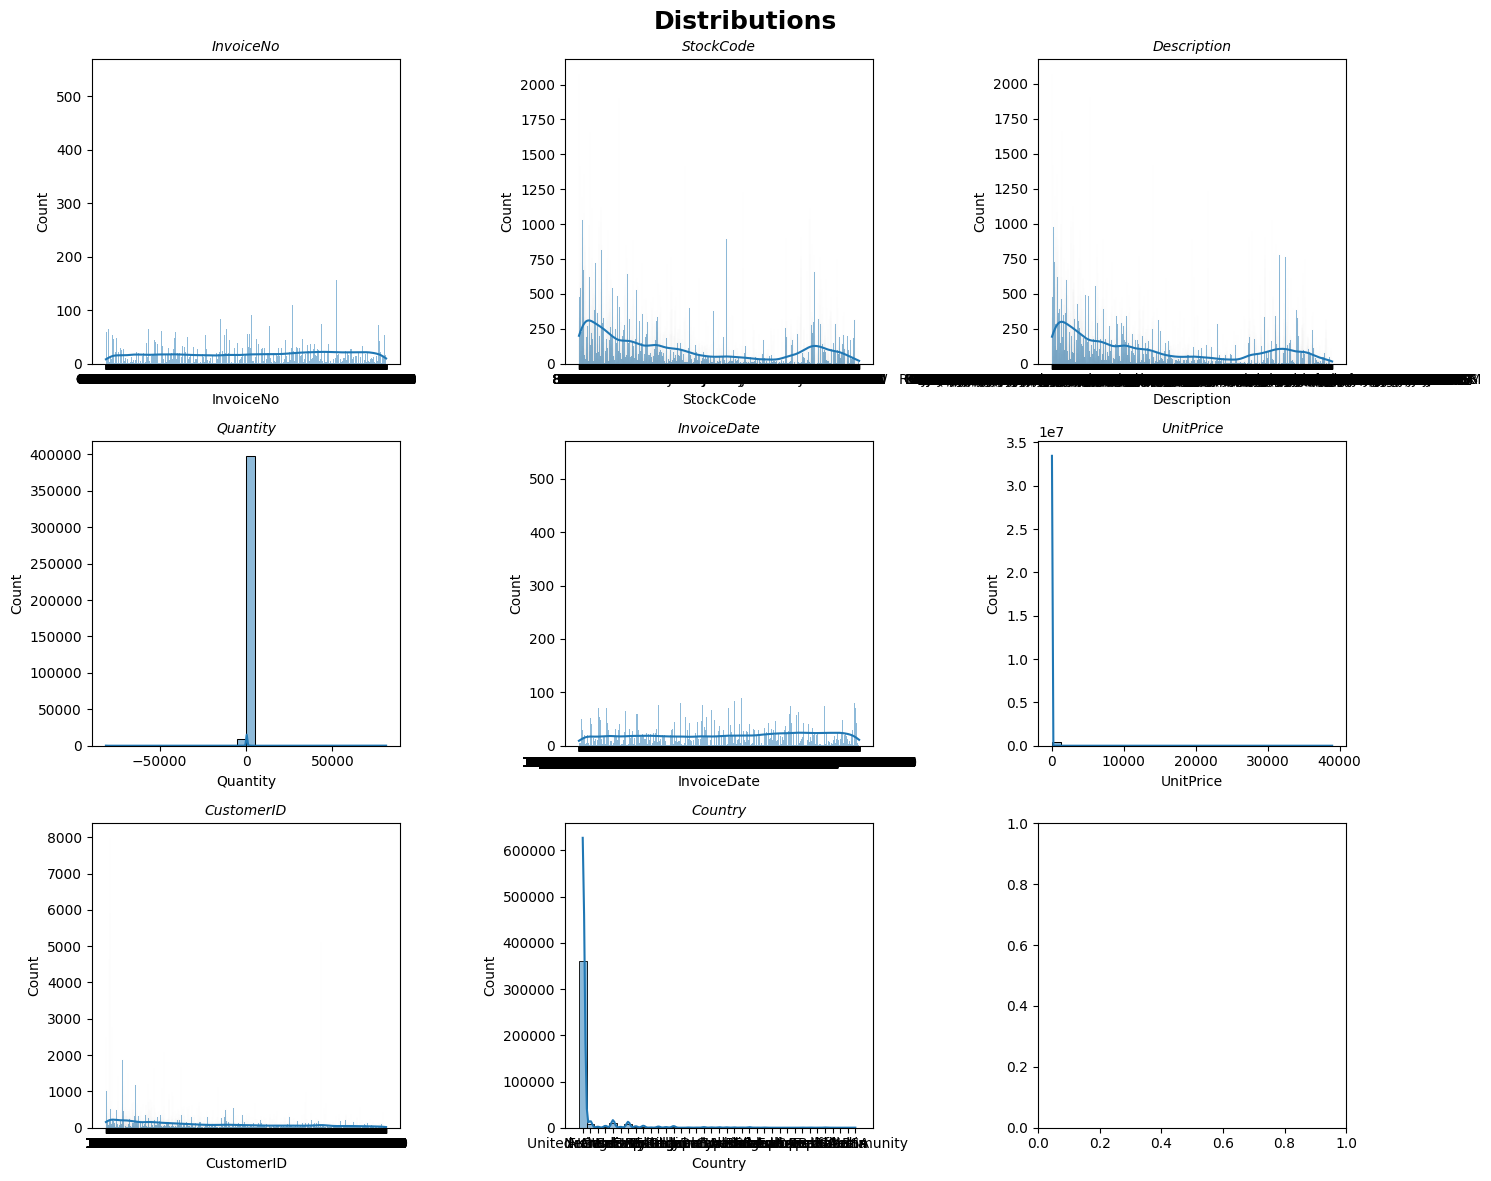

In [22]:
columns = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country']

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(15,12))
fig.suptitle("Distributions", fontsize = 18, fontweight = "bold")

for i, col in enumerate(columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    sns.histplot(data = df, x = col, kde=True, ax=ax, bins=30) #bins : kaç çubuk ile gösterileceğini belirler
    ax.set_title(col, fontsize=10, fontstyle = "italic")

plt.tight_layout()
plt.show()

In [23]:
def find_outliers_iqr(df, threshold = 1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]
        
        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }
    return pd.DataFrame(outlier_summary)

In [24]:
find_outliers_iqr(df)

,Quantity,UnitPrice
outlier_count,26682.00000,36051.000000
outlier_percentage,6.55853,8.861463
lower_bound,-13.00000,-2.500000
upper_bound,27.00000,7.500000


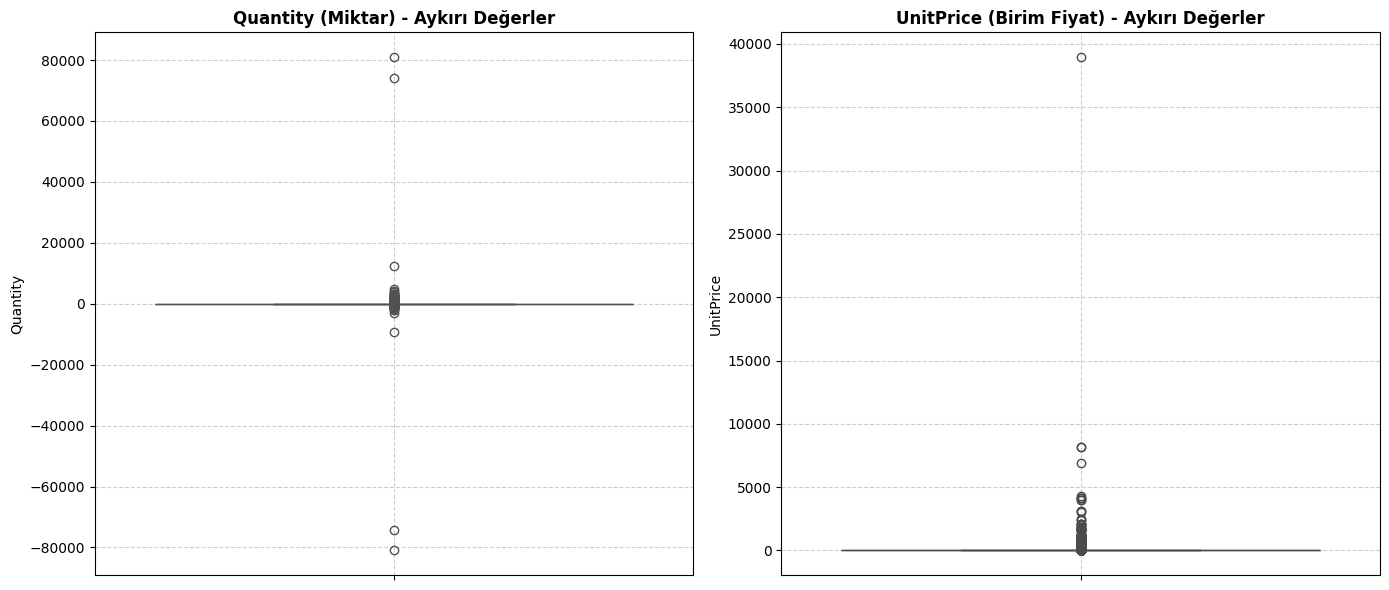

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'], color='#3498db')
plt.title('Quantity (Miktar) - Aykırı Değerler', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.boxplot(y=df['UnitPrice'], color='#2ecc71')
plt.title('UnitPrice (Birim Fiyat) - Aykırı Değerler', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [27]:
#0'ın altında kalan miktarlar iadeyi , 0 birim fiyata sahip olanlar ise hediye bedava ve hataları gösteriyor
df = df[(df['Quantity']>0)& (df['UnitPrice']>0)]

In [29]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']

In [30]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [38]:
import datetime as dt
datee =df['InvoiceDate'].max() + dt.timedelta(days=1)

In [39]:
#müşteri bazlı özet bir tabloya çeviriyoruz ki algoritma modeli anlasın
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (datee - date.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                          # Frequency
    'TotalPrice': 'sum'                                             # Monetary
})

In [40]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [41]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


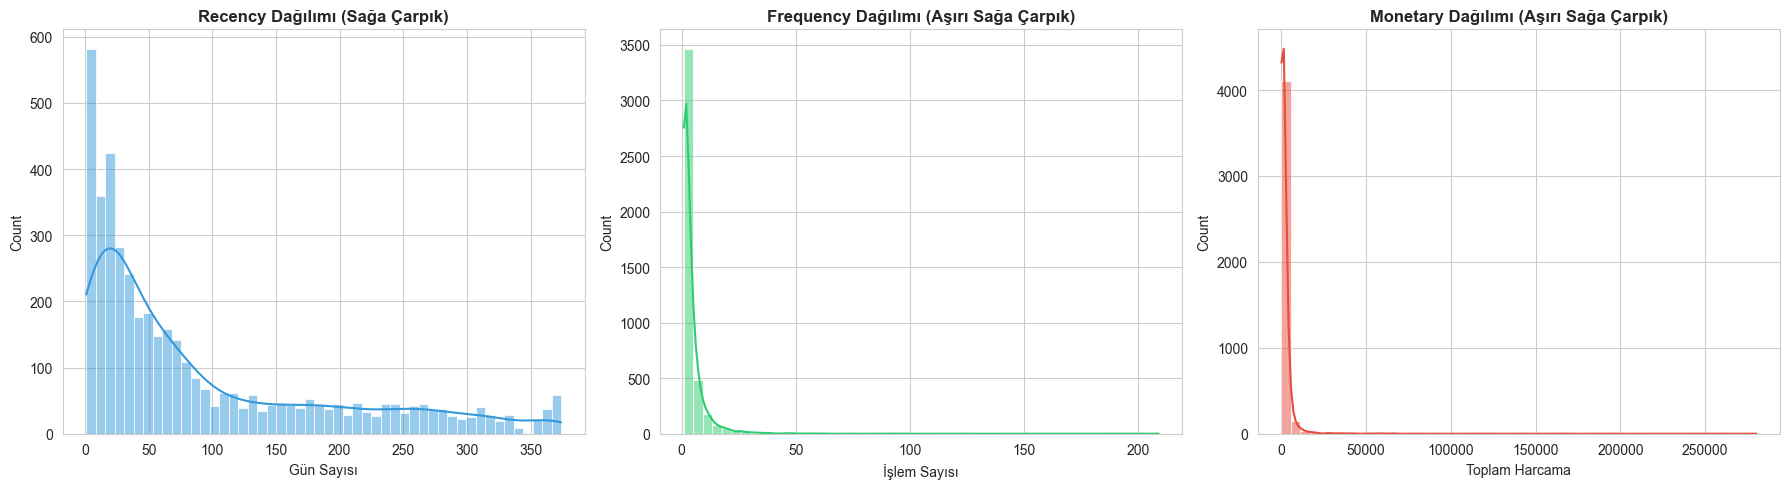

In [43]:
plt.figure(figsize=(18, 5))

# Recency 
plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], bins=50, kde=True, color='#3498db')
plt.title('Recency Dağılımı (Sağa Çarpık)', fontsize=12, fontweight='bold')
plt.xlabel('Gün Sayısı')

# Frequency 
plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], bins=50, kde=True, color='#2ecc71')
plt.title('Frequency Dağılımı (Aşırı Sağa Çarpık)', fontsize=12, fontweight='bold')
plt.xlabel('İşlem Sayısı')

# Monetary
plt.subplot(1, 3, 3)
sns.histplot(rfm['Monetary'], bins=50, kde=True, color='#e74c3c')
plt.title('Monetary Dağılımı (Aşırı Sağa Çarpık)', fontsize=12, fontweight='bold')
plt.xlabel('Toplam Harcama')

plt.tight_layout()
plt.show()

In [44]:
#sağa çarpıklık hakim
from sklearn.preprocessing import StandardScaler

rfm_log = np.log1p(rfm)

ss = StandardScaler()
rfm_scaled = ss.fit_transform(rfm_log)

rfm_scaled=pd.DataFrame(rfm_scaled , columns=rfm.columns,index=rfm.index)

In [45]:
rfm_scaled

,Recency,Frequency,Monetary
CustomerID,,,
12346,1.461993,-0.955214,3.706225
12347,-2.038734,1.074425,1.411843
12348,0.373104,0.386304,0.716489
12349,-0.623086,-0.955214,0.698739
12350,1.424558,-0.955214,-0.618962
...,...,...,...
18280,1.343533,-0.955214,-1.106875
18281,1.024749,-0.955214,-1.740933
18282,-1.218940,-0.361583,-1.118121


In [48]:
#sadece 4 sütuna düşürdüğümüz için pca'ye gerek yok kmeans yapalım
from sklearn.cluster import KMeans

inertia= []
k_araligi = range(1, 10)

for k in k_araligi:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

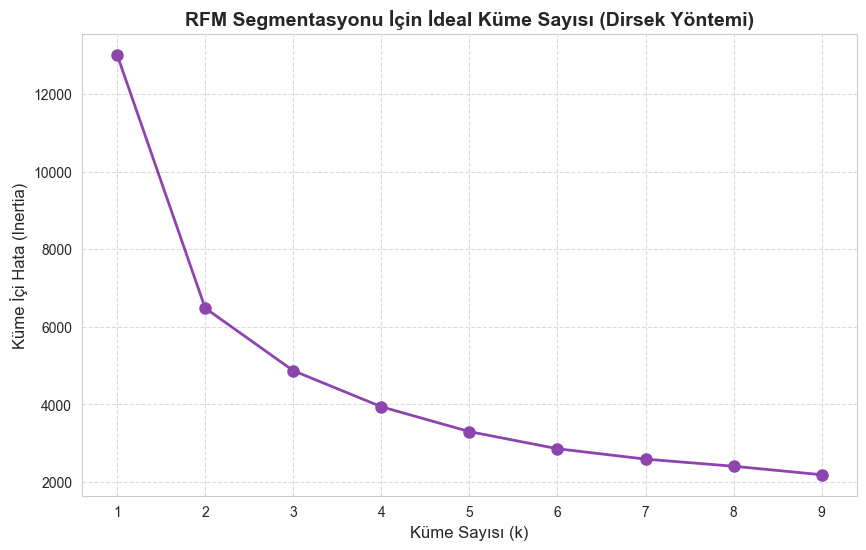

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(k_araligi, inertia, marker='o', linestyle='-', color='#8e44ad', linewidth=2, markersize=8)
plt.title('RFM Segmentasyonu İçin İdeal Küme Sayısı (Dirsek Yöntemi)', fontsize=14, fontweight='bold')
plt.xlabel('Küme Sayısı (k)', fontsize=12)
plt.ylabel('Küme İçi Hata (Inertia)', fontsize=12)
plt.xticks(k_araligi)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [53]:
from sklearn.metrics import silhouette_score

k_value = 4
kmeans = KMeans(n_clusters=k_value, random_state=42, n_init='auto')
must_kumeleri = kmeans.fit_predict(rfm_scaled)

print(silhouette_score(rfm_scaled,must_kumeleri))

0.3371343622222519


In [61]:
from sklearn.metrics import silhouette_score

k_value = 3
kmeans = KMeans(n_clusters=k_value, random_state=42, n_init='auto')
must_kumeleri = kmeans.fit_predict(rfm_scaled)

print(silhouette_score(rfm_scaled,must_kumeleri))

0.3360125435154917


In [54]:
from sklearn.metrics import davies_bouldin_score,calinski_harabasz_score

print("calinski : ",calinski_harabasz_score(rfm_scaled,must_kumeleri))
print("davies : " , davies_bouldin_score(rfm_scaled,must_kumeleri))

calinski :  3328.9939678047613
davies :  1.010147208011302


In [55]:
#hdbscan
from sklearn.cluster import HDBSCAN

hdbscan_model = HDBSCAN(min_cluster_size=50)
hdbscan_kumeler = hdbscan_model.fit_predict(rfm_scaled)

c:\Users\merve\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [56]:
kume_sayisi = len(set(hdbscan_kumeler)) - (1 if -1 in hdbscan_kumeler else 0)
gurultu_sayisi = list(hdbscan_kumeler).count(-1)

print("Oluşturulan Küme Sayısı:",kume_sayisi)
print("Gürültü Olarak İşaretlenen Müşteri Sayısı (-1 etiketi):",gurultu_sayisi)

Oluşturulan Küme Sayısı: 2
Gürültü Olarak İşaretlenen Müşteri Sayısı (-1 etiketi): 589


In [60]:
rfm['KumeNum'] = must_kumeleri

profil_ozeti = rfm.groupby('KumeNum').agg({
    'Recency': 'mean',      
    'Frequency': 'mean',    
    'Monetary': 'mean',   
    'KumeNum': 'count'      
}).rename(columns={'KumeNum': 'Mus_kumeleri'}).round(2)

profil_ozeti.style.background_gradient(cmap='YlGnBu')

,Recency,Frequency,Monetary,Mus_kumeleri
KumeNum,,,,
0,18.120000,2.150000,551.820000,837
1,12.130000,13.710000,8074.270000,716
2,71.080000,4.080000,1802.830000,1173
3,182.500000,1.320000,343.450000,1612


In [62]:
#frequency ve monetary değeri yüksek olanlar VIP -1.sütun
#recency değeri çok yüksek frequency ve monetary düşük olanlar PASİF - 3.sütun
#Monetary ortalama SEYREK - 0.sütun
#2.sütun - ise frequency düşükse 'YENİ' ama recency yüksekse 'RİSKLİ' 

In [64]:
rfm_segment_isimleri = {
    1: 'VIP',
    3: 'Uyuyan',
    0: 'Seyrek',
    2: 'Riskli Müşteriler' 
}

rfm['Musteri_Profili'] = rfm['KumeNum'].map(rfm_segment_isimleri)

print(rfm['Musteri_Profili'].value_counts())

Musteri_Profili
Uyuyan               1612
Riskli Müşteriler    1173
Seyrek                837
VIP                   716
Name: count, dtype: int64


In [67]:
import pickle

rfm_model_paketi = {
    'scaler': ss,
    'kmeans': kmeans,
    'segment_isimleri': rfm_segment_isimleri
}

with open('rfm_segmentasyon_modeli.pkl', 'wb') as f:
    pickle.dump(rfm_model_paketi, f)
    